In [1]:
from pathlib import Path
import re
import pandas as pd
import seaborn as sns

In [2]:
WORKLOADS = ["faiss_10M", "lulesh2.0_s400", "DuckDB-TPCH-sf100", "DuckDB-TPCDS-sf100", "mg.D.x", "XSBench", "pr-kron.sg", "pr-twitter.sg", "bc-kron.sg", "bc-twitter.sg"]

In [3]:
def parse_time_value(raw: str) -> float:
    """Convert strings like '7m56.676s' into seconds."""
    
    raw = raw.strip()
    match = re.fullmatch(r"(?:(\d+)m)?([0-9.]+)s", raw)
    if not match:
        raise ValueError(f"Unrecognized time format: {raw}")
    minutes = int(match.group(1) or 0)
    seconds = float(match.group(2))
    return minutes * 60 + seconds

def parse_time_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "\t" not in line:
                continue
            key, value = line.split("\t", 1)
            metrics[key] = parse_time_value(value)
    return metrics

def extract_mib(path: Path) -> int | None:
    match = re.search(r"(\d+)MiB", path.name)
    return int(match.group(1)) if match else None


def extract_run(path: Path) -> int | None:
    match = re.search(r"run(\d+)", path.name)
    return int(match.group(1)) if match else None

def parse_log_file(path: Path) -> dict:
    metrics = {}
    with path.open() as f:
        for line in f:
            line = line.strip()
            if not line or "=" not in line:
                continue
            key, value = line.split("=", 1)
            metrics[key.strip()] = float(value.strip())
    return metrics

In [4]:
dfs = []

for workload in WORKLOADS:
    roots = {
        "arms-6.18": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.18/{workload}")),
        "hybridtier": ("6.2+", (Path(f"/users/zimooo2/tiering_solutions/times/hybridtier/{workload}"))),
        "arms-6.2": ("6.2+", Path(f"/users/zimooo2/tiering_solutions/times/arms-6.2/{workload}")),
        "model": ("6.18", Path(f"/users/zimooo2/tiering_solutions/times/model/{workload}")),
        "nomad": ("5.13-rc6+", Path(f"/users/zimooo2/tiering_solutions/times/nomad/{workload}")),
    }

    records: list[dict] = []
    for label, (kernel, root) in roots.items():
        for path in sorted(root.glob("*.time")):
            if "train" in path.name:
                continue
            metrics = parse_time_file(path)
            try:
                log_metrics = parse_log_file(Path(f"{path.parent}/max_dram_hugepages_{path.stem}.log"))
            except FileNotFoundError:
                log_metrics = {}
                
                
            
                
            m = re.search(
                r"_discounted_reward_(\d+)_.*_l2-(true|false)_(\d+)_([0-9]*\.?[0-9]+)\.time$",
                path.name,
            )
            parsed = {}
            if m:
                parsed = {
                    "discounted_reward": int(m.group(1)),
                    "minmax": m.group(2) == "true",
                    "hist_length": int(m.group(3)),
                    "penalty": float(m.group(4)),
                }

            records.append({
                "policy": label,
                "kernel": kernel,
                "file": path.name,
                "MiB": extract_mib(path),
                "run": extract_run(path),
                **metrics,
                **log_metrics,
                **parsed,
            })

    df = pd.DataFrame(records)
    df["workload"] = workload

    dfs.append(df)
df = pd.concat(dfs, ignore_index=True)
df


arms_df = (
    df.loc[df["policy"] == "arms", ["MiB", "workload", "real"]]
    .rename(columns={"real": "real_arms"})
    .drop_duplicates(subset=["MiB", "workload"])
)

df = (
    df.merge(arms_df, on=["MiB", "workload"], how="left")
)

# >1 means faster than arms, <1 means slower than arms
df["relative_score_vs_arms"] = df["real_arms"] / df["real"]
df

,policy,kernel,file,MiB,run,real,user,sys,discounted_reward,minmax,hist_length,penalty,workload,real_arms,relative_score_vs_arms
0,arms-6.18,6.18,10000MiB_run1.time,10000,1,483.170,0.010,0.024,NaN,NaN,NaN,NaN,faiss_10M,NaN,NaN
1,arms-6.18,6.18,10000MiB_run2.time,10000,2,491.678,0.013,0.022,NaN,NaN,NaN,NaN,faiss_10M,NaN,NaN
2,arms-6.18,6.18,10000MiB_run3.time,10000,3,504.333,0.013,0.020,NaN,NaN,NaN,NaN,faiss_10M,NaN,NaN
3,arms-6.18,6.18,4000MiB_run1.time,4000,1,536.373,0.012,0.022,NaN,NaN,NaN,NaN,faiss_10M,NaN,NaN
4,arms-6.18,6.18,4000MiB_run2.time,4000,2,532.691,0.010,0.023,NaN,NaN,NaN,NaN,faiss_10M,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
632,nomad,5.13-rc6+,6000MiB_run2.time,6000,2,221.316,0.009,0.019,NaN,NaN,NaN,NaN,bc-twitter.sg,NaN,NaN
633,nomad,5.13-rc6+,6000MiB_run3.time,6000,3,556.168,0.007,0.020,NaN,NaN,NaN,NaN,bc-twitter.sg,NaN,NaN
634,nomad,5.13-rc6+,8000MiB_run1.time,8000,1,194.026,0.012,0.016,NaN,NaN,NaN,NaN,bc-twitter.sg,NaN,NaN
635,nomad,5.13-rc6+,8000MiB_run2.time,8000,2,460.477,0.009,0.018,NaN,NaN,NaN,NaN,bc-twitter.sg,NaN,NaN


In [5]:
df[df["MiB"] > 1000].sort_values(["MiB", "workload", "policy"]).to_csv("summary.csv", index=False)

DuckDB-TPCDS-sf100


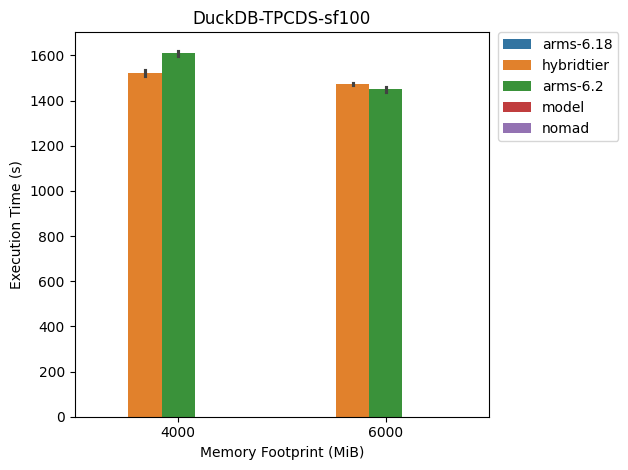

DuckDB-TPCH-sf100


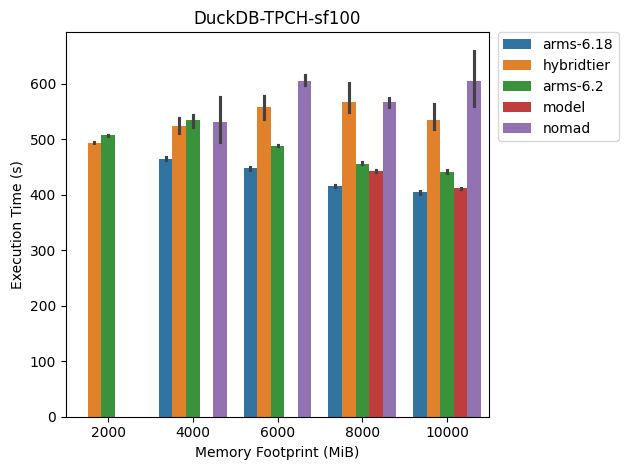

XSBench


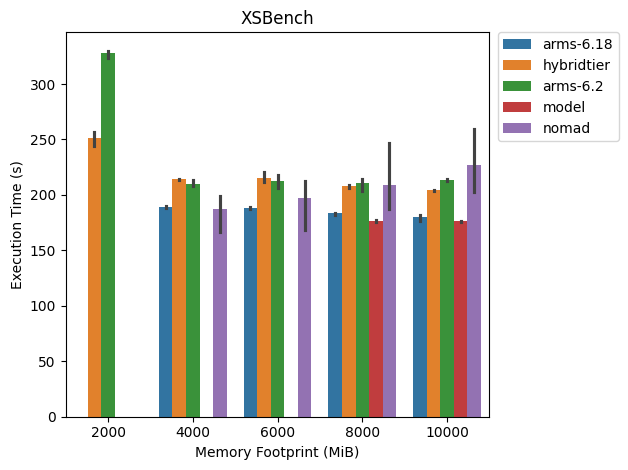

bc-kron.sg


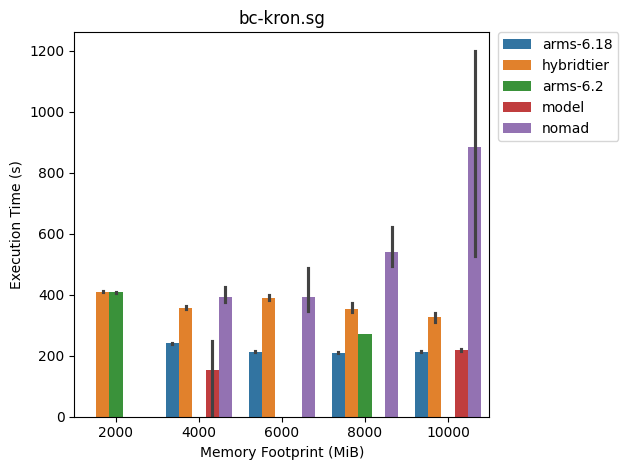

bc-twitter.sg


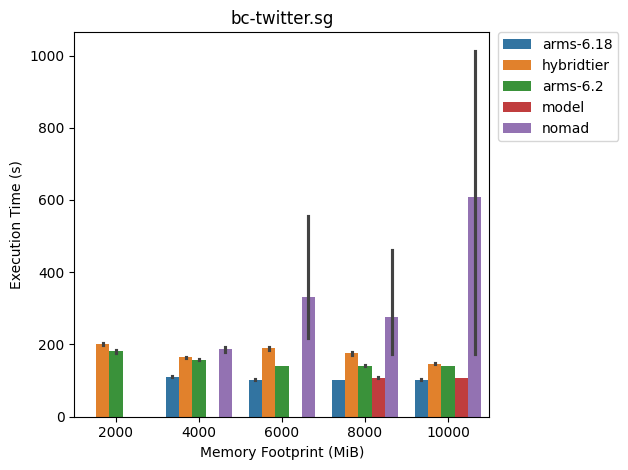

faiss_10M


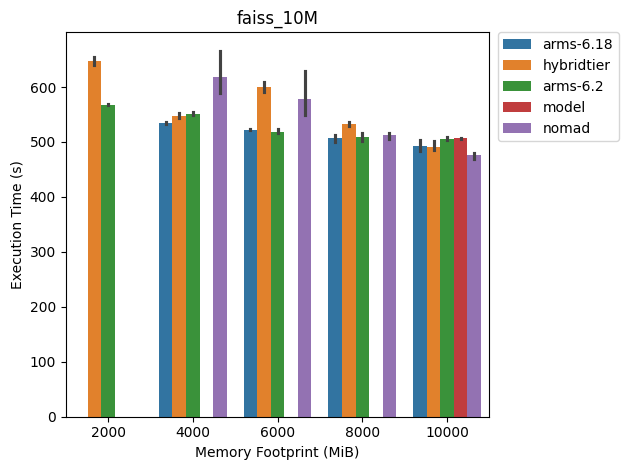

lulesh2.0_s400


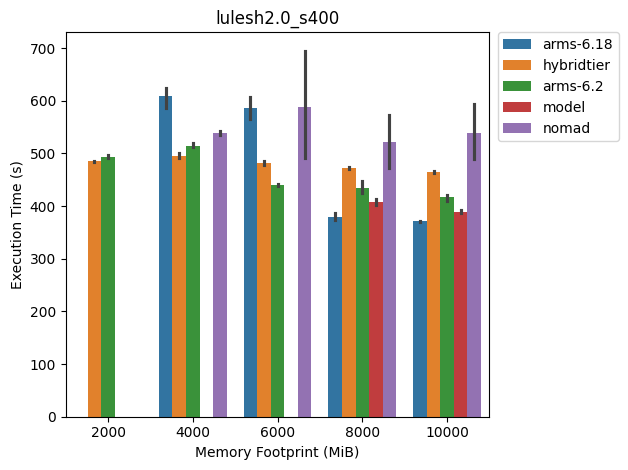

mg.D.x


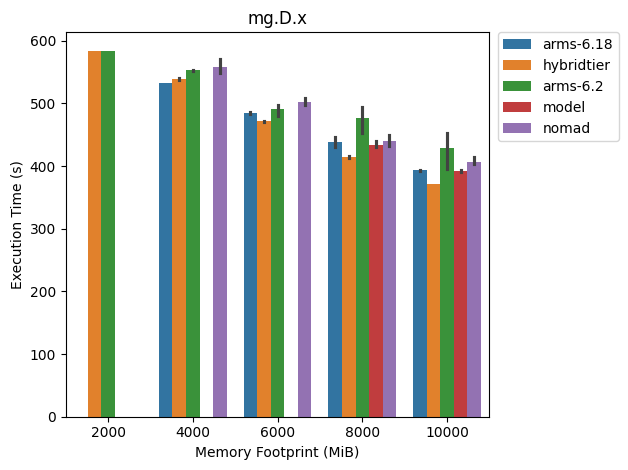

pr-kron.sg


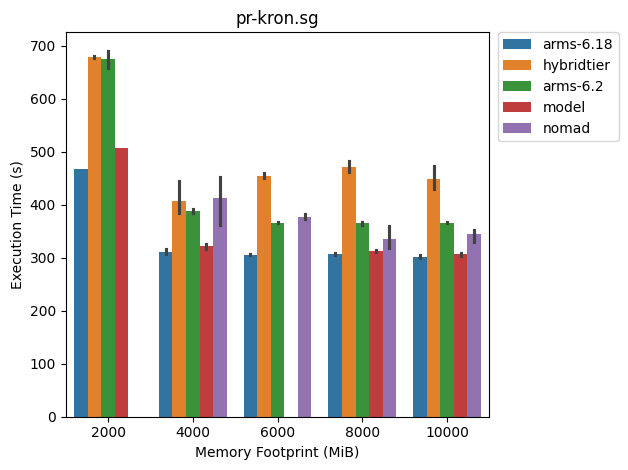

pr-twitter.sg


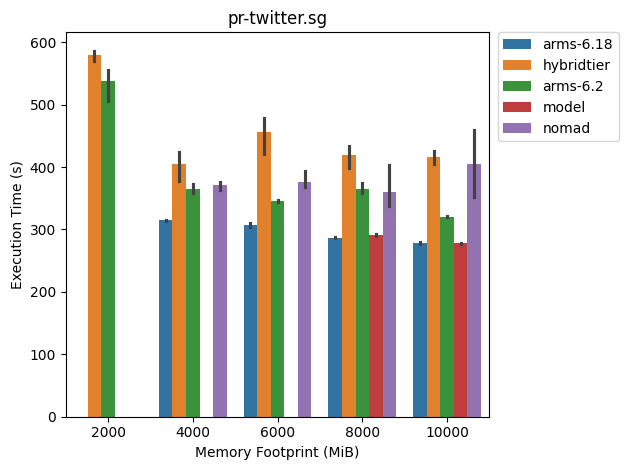

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

policy_order = list(dict.fromkeys(df["policy"]))
policy_palette = dict(zip(policy_order, sns.color_palette(n_colors=len(policy_order))))

def minmax_interval(values):
    return values.min(), values.max()

for workload_group in df[df["MiB"] > 1000].groupby("workload"):
    print(workload_group[0])
    plt.figure(figsize=(14, 8))
    ax = sns.barplot(
        workload_group[1],
        x="MiB",
        y="real",
        hue="policy",
        hue_order=policy_order,
        palette=policy_palette,
        estimator="mean",
        errorbar=minmax_interval,
    )
    ax.set(title=workload_group[0], xlabel="Memory Footprint (MiB)", ylabel="Execution Time (s)")
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
    plt.tight_layout()
    plt.show()